In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_r")

# Load final clean dataset
df = pd.read_csv('../../data/data_roles_final.csv')
# Only rows with salary
df_sal = df[df['salary_final'].notna() & 
            (df['salary_final'] > 20000) & 
            (df['salary_final'] < 400000)].copy()

print("Total roles:", len(df))
print("Roles with salary data:", len(df_sal))

Total roles: 8819
Roles with salary data: 2854


TOP 15 CITIES

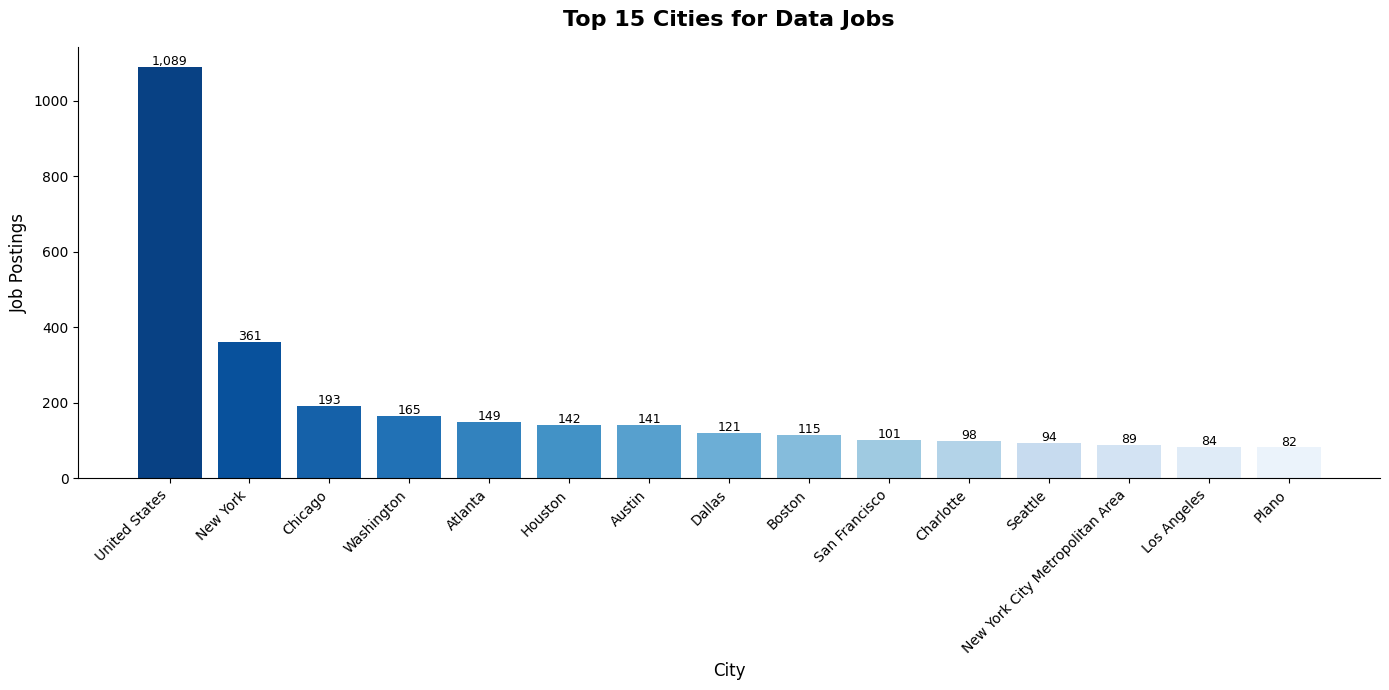

✅ Top city: United States with 1089 jobs


In [4]:
city_counts = df['city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(city_counts.index,
              city_counts.values,
              color=sns.color_palette("Blues_r", 15))
ax.set_title('Top 15 Cities for Data Jobs',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Job Postings', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, city_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../data/final_chart2_cities.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top city:", city_counts.index[0],
      "with", city_counts.values[0], "jobs")

Top 15 Job Titles

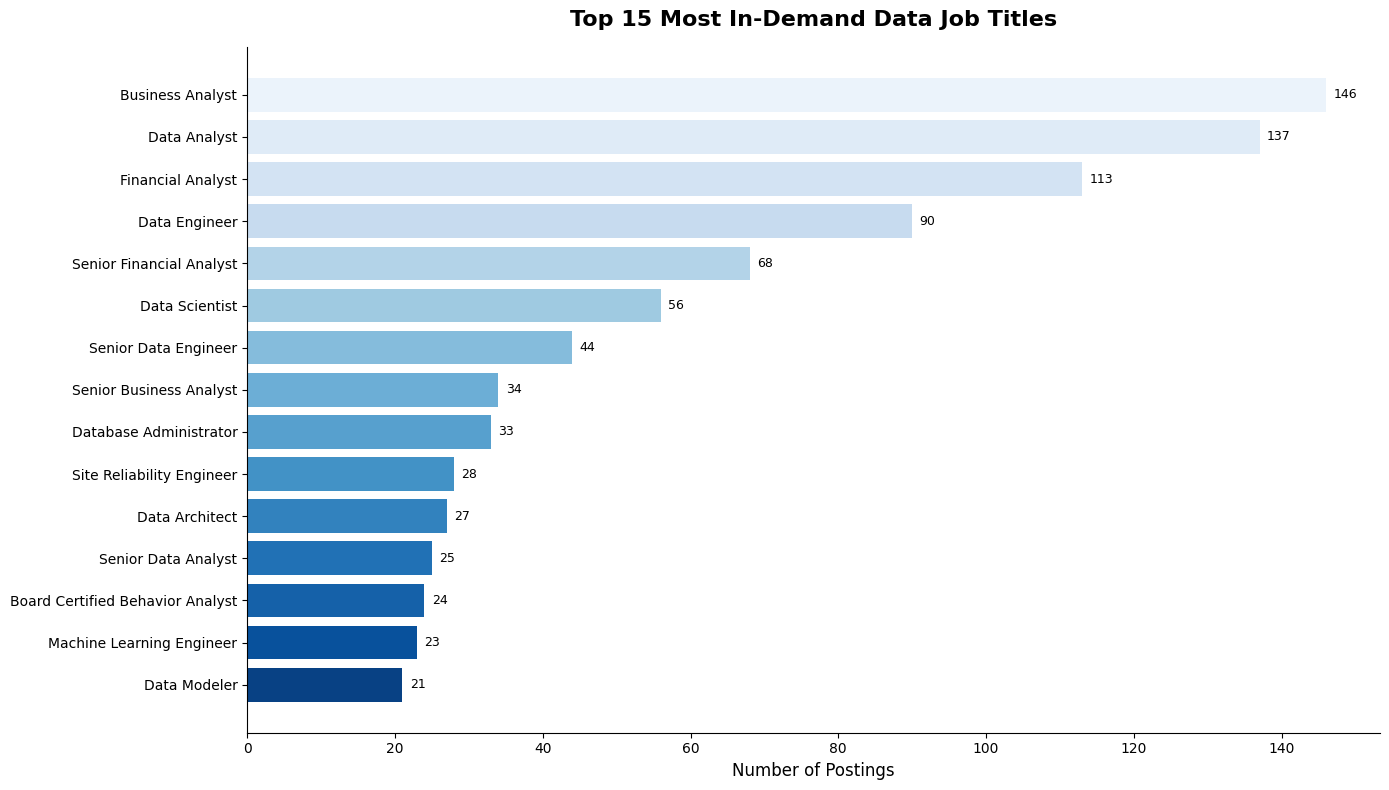

✅ Top 5 titles: ['Business Analyst', 'Data Analyst', 'Financial Analyst', 'Data Engineer', 'Senior Financial Analyst']


In [6]:
# Remove BCBA — not a data role
exclude = ['board certified behavior analyst (bcba)']
title_counts = df[
    ~df['title'].str.lower().isin(exclude)
]['title'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(title_counts.index[::-1],
        title_counts.values[::-1],
        color=sns.color_palette("Blues_r", 15))
ax.set_title('Top 15 Most In-Demand Data Job Titles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Postings', fontsize=12)

for i, val in enumerate(title_counts.values[::-1]):
    ax.text(val + 1, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../data/final_chart3_titles.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top 5 titles:", title_counts.index[:5].tolist())

 Salary by Experience Level

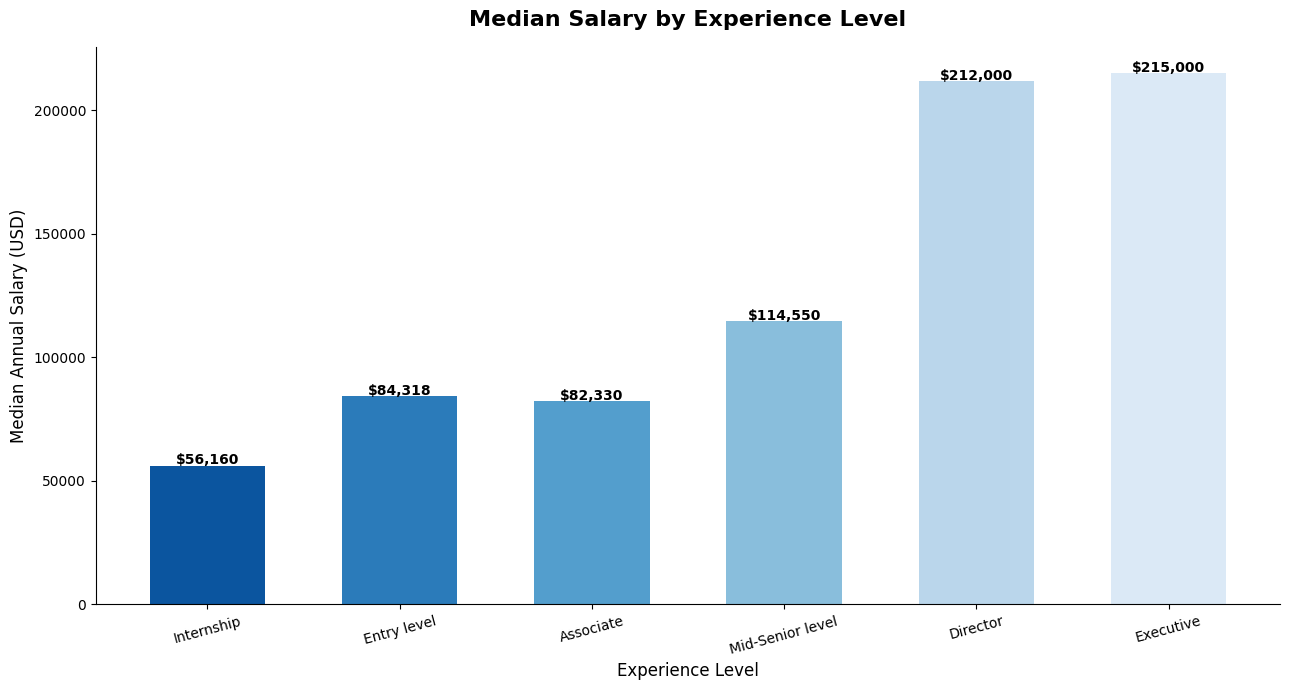

Internship: $56,160
Entry level: $84,318
Associate: $82,330
Mid-Senior level: $114,550
Director: $212,000
Executive: $215,000


In [7]:
exp_order = ['Internship', 'Entry level', 'Associate',
             'Mid-Senior level', 'Director', 'Executive']

exp_salary = df_sal[
    df_sal['formatted_experience_level'].isin(exp_order)
].groupby('formatted_experience_level')[
    'salary_final'].median().reindex(exp_order).dropna()

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(exp_salary.index,
              exp_salary.values,
              color=sns.color_palette("Blues_r", len(exp_salary)),
              width=0.6)
ax.set_title('Median Salary by Experience Level',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Experience Level', fontsize=12)
ax.set_ylabel('Median Annual Salary (USD)', fontsize=12)
plt.xticks(rotation=15)

for bar, val in zip(bars, exp_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${val:,.0f}', ha='center',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../../data/final_chart4_exp_salary.png',
            dpi=150, bbox_inches='tight')
plt.show()

for exp, sal in exp_salary.items():
    print(f"{exp}: ${sal:,.0f}")

 Top 10 Highest Paying Job Titles

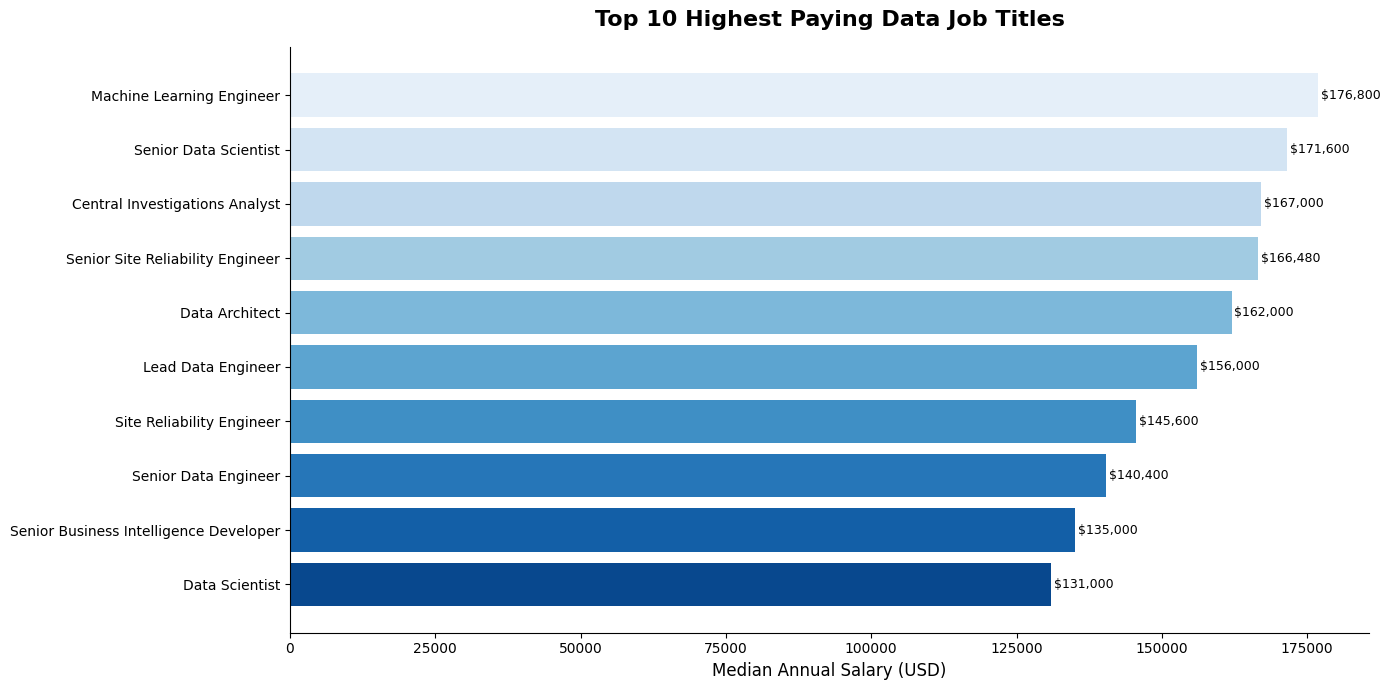

✅ Highest paying title: Machine Learning Engineer at $ 176800.0


In [9]:
title_salary = df_sal.groupby('title')[
    'salary_final'].agg(['median', 'count']).reset_index()
title_salary = title_salary[
    title_salary['count'] >= 5
].sort_values('median', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(title_salary['title'][::-1],
               title_salary['median'][::-1],
               color=sns.color_palette("Blues_r", 10))
ax.set_title('Top 10 Highest Paying Data Job Titles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Median Annual Salary (USD)', fontsize=12)

for i, val in enumerate(title_salary['median'][::-1]):
    ax.text(val + 500, i, f'${val:,.0f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../data/final_chart5_title_salary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Highest paying title:",
      title_salary.iloc[0]['title'],
      "at $", round(title_salary.iloc[0]['median'], 0))

 Salary Distribution

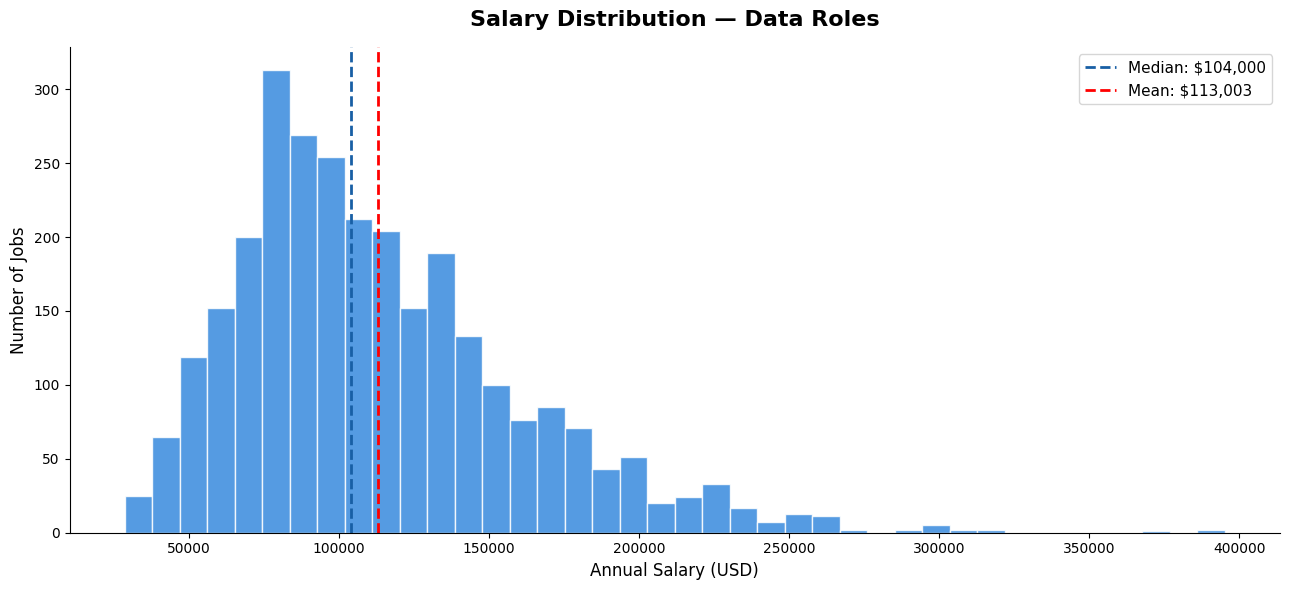

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(df_sal['salary_final'],
        bins=40, color='#378ADD',
        edgecolor='white', alpha=0.85)
ax.set_title('Salary Distribution — Data Roles',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Annual Salary (USD)', fontsize=12)
ax.set_ylabel('Number of Jobs', fontsize=12)
ax.axvline(df_sal['salary_final'].median(),
           color='#185FA5', linestyle='--',
           linewidth=2, label=f'Median: ${df_sal["salary_final"].median():,.0f}')
ax.axvline(df_sal['salary_final'].mean(),
           color='red', linestyle='--',
           linewidth=2, label=f'Mean: ${df_sal["salary_final"].mean():,.0f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../../data/final_chart7_salary_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()

Work Type Breakdown

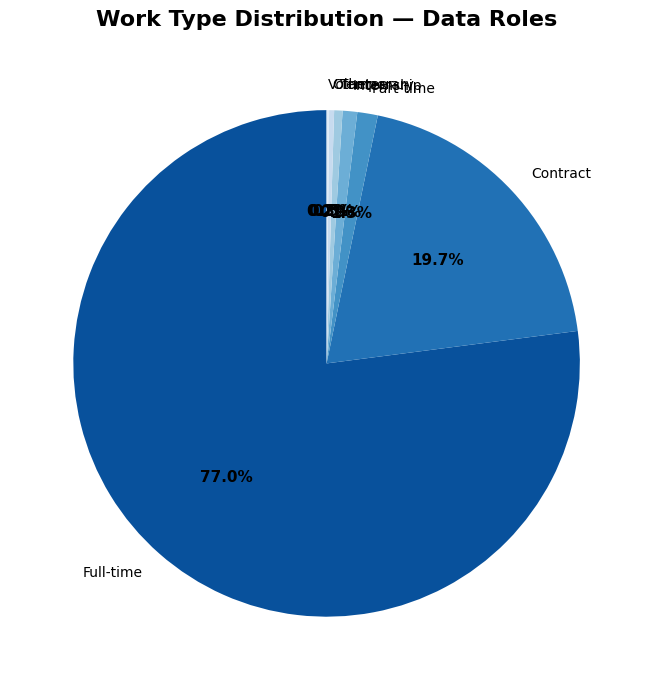

✅ Work type breakdown:
 formatted_work_type
Full-time     6795
Contract      1738
Part-time      115
Internship      82
Temporary       47
Other           28
Volunteer       14
Name: count, dtype: int64


In [12]:
work_counts = df['formatted_work_type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette("Blues_r", len(work_counts))
wedges, texts, autotexts = ax.pie(
    work_counts.values,
    labels=work_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Work Type Distribution — Data Roles',
             fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../../data/final_chart8_worktype.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Work type breakdown:\n", work_counts)